# Notebook 03 — Representativeness

**Purpose:** Descriptive characterization of the 64-trial evidence base:
publication trend, geography, sample sizes, healthcare setting, baseline
comparison against 4 reference cohorts, PROGRESS-Plus reporting completeness,
and digital strategy landscape.

**Data Flow:**
| Direction | File | From / To |
|-----------|------|-----------|
| Input | `data/processed/arms.csv` | Notebook 00 |
| Input | `data/processed/papers.csv` | Notebook 00 |
| Input | `outputs/tables/per_paper_one_na.csv` | Notebook 01 (ambiguous flags) |
| Output | `outputs/figures/fig1–5` | Thesis Figures 3–8 |
| Output | `outputs/tables/table1–5` | Thesis Results §3.2–3.5 |

**Prerequisite notebooks:** N00 (arms + papers), N01 (per_paper_one_na).


## Section 0: Setup

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks"          else Path().resolve()
sys.path.insert(0, str(ROOT))

# ── External libraries ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Project modules ────────────────────────────────────────────────────────
# Data loading — load arms + papers from N00; reference cohorts for comparison
from src.data_loading import load_arms, load_references
from src.data_loading import parse_structured_array

# Aggregation — paper-level weighted means, pooled estimates, equity reporting
from src.aggregation import paper_level_weighted_mean
from src.aggregation import pool_across_papers, unweighted_mean_across_papers
from src.aggregation import aggregate_boolean_at_paper
from src.aggregation import aggregate_equity_reporting
from src.aggregation import pooled_within_trial_sd

# Statistics — SMD (Cohen's d/h) comparing trial pool vs reference cohorts
from src.statistics import compute_smd_table

# Plotting — colour palette, figures, and combined corpus/completeness scripts
from src.plotting import PALETTE, BLUE, ORANGE, GREEN, RED, GRAY
from src.plotting import save_figure
from src.plotting import bar_with_ci, forest_plot_means
from src.plotting import histogram_with_stats
from src.plotting import scatter_with_regression
from src.plotting import trial_scatter_means
from src.plotting import forest_plot_smd
from src.plotting import stacked_bar_crosstab, stacked_bar_crosstab_dual
from scripts.build_fig_corpus_combined_a import build_fig_corpus_combined

# Geography — resolve country/multi-country string → continent label
from src.geography import get_continent

# ── Paths ──────────────────────────────────────────────────────────────────
plt.ion()

ARMS_PATH = ROOT / "data" / "processed" / "arms.csv"
PAPERS_PATH = ROOT / "data" / "processed" / "papers.csv"
PER_PAPER_NA_PATH = ROOT / "outputs" / "tables" / "pipeline" / "per_paper_one_na.csv"
OUTPUT_TABLES = ROOT / "outputs" / "tables"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)


## Section 1: Load processed data

In [2]:
# Load processed data from N00 and N01. Separate treatment arms for digital
# strategy analysis. Load ambiguous NA flags from N01 inter-run consistency.
arms = load_arms(ARMS_PATH)
int_arms = arms[arms["arm"].isin(["treat1", "treat2"])]
papers = pd.read_csv(PAPERS_PATH)
refs = load_references()

print(f"Arms: {arms.shape}, Papers: {len(papers)}")
print(f"N papers = {papers['cov_nr'].nunique()}, N arms = {len(arms)}")

# Load ambiguous NA flags from notebook 01
ambiguous_na = None
if PER_PAPER_NA_PATH.exists():
    na_df = pd.read_csv(PER_PAPER_NA_PATH)
    pp_fields = ['ses_income', 'ses_living_situation', 'ses_relationship_status',
                 'ses_job_status', 'ses_living_location', 'educational_level',
                 'ethnicity', 'health_literacy', 'digital_literacy']
    pp_na = na_df[na_df['field_name'].isin(pp_fields)]
    # Build dict: field_name -> set of cov_nr with one-NA
    ambiguous_na = {}
    for field in pp_fields:
        subset = pp_na[pp_na['field_name'] == field]
        if len(subset) > 0:
            ambiguous_na[field] = set(subset['cov_nr'].unique())
    print(f"Ambiguous-NA fields loaded: {list(ambiguous_na.keys())}")
else:
    print("No per_paper_one_na.csv found — skipping ambiguous classification")


Arms: (134, 71), Papers: 64
N papers = 64, N arms = 134
Ambiguous-NA fields loaded: ['ses_income', 'ses_living_situation', 'ses_relationship_status', 'educational_level']


## Section 2.1: Publication year distribution

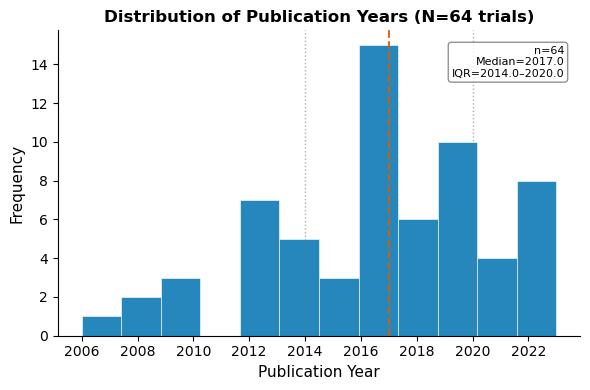

Year range: 2006-2023, median: 2017, mean: 2016.8, SD: 4.0


In [3]:
# Publication year distribution. Three periods reflect digital-health phases:
# 2006–2014 (proof-of-concept), 2015–2019 (smartphone consolidation),
# 2020–2023 (pandemic-accelerated).

# fig1a: year histogram
years = papers['publication_year'].dropna()
fig = histogram_with_stats(
    years.values,
    xlabel="Publication Year", title="Distribution of Publication Years (N=64 trials)",
    bins=12, color=BLUE, integer_x=True,
)
save_figure(fig, "fig1b_papers_by_year")
print(f"Year range: {years.min():.0f}-{years.max():.0f}, median: {years.median():.0f}, mean: {years.mean():.1f}, SD: {years.std():.1f}")

# Continent mapping + two bucket systems for stacked bars
papers['continent'] = papers['country'].apply(get_continent)
papers['bucket_eq'] = pd.cut(papers['publication_year'],
                              bins=[2005, 2011, 2017, 2024],
                              labels=['2006-2011', '2012-2017', '2018-2023'])
papers['bucket_ph'] = pd.cut(papers['publication_year'],
                              bins=[2005, 2014, 2019, 2024],
                              labels=['2006-2014', '2015-2019', '2020-2023'])

# Combined figure (continent + setting, dual-axis)
# Generate combined corpus figure (continent + healthcare setting)

## Section 2.2: Geographic distribution

Multi-country strings are parsed by `get_continent()`: if all countries
resolve to the same continent, that continent is used; otherwise the
paper is labelled "Multi-continent". Country counts below are printed as-is
from the papers table (including compound entries like "Belgium and Spain").


In [4]:
# Country and continent distribution. Multi-country strings counted as-is.
# get_continent() resolves them to continent labels.
country_counts = papers['country'].value_counts()
cont_counts = papers['continent'].value_counts()

# Print continent distribution first
print(f"Unique countries/regions: {len(country_counts)}")
print("\nContinent distribution:")
print(cont_counts.to_string())

# Print country distribution second
print("\n")
print(country_counts.to_string())

# Save table
geo_df = pd.DataFrame({
    'region': country_counts.index,
    'n_papers': country_counts.values,
})
geo_df = geo_df.sort_values('n_papers', ascending=False)
geo_df.to_csv(OUTPUT_TABLES / 'table1b_geography.csv', index=False)
print("\nSaved: table1_geography.csv")


Unique countries/regions: 21

Continent distribution:
continent
Europe             37
North America      13
Asia                7
Oceania             6
Multi-continent     1


country
Denmark                                                   12
USA                                                       11
UK                                                         8
Australia                                                  5
Netherlands                                                4
Spain                                                      3
Taiwan                                                     3
China                                                      3
Belgium                                                    2
Canada                                                     2
Italy                                                      1
New Zealand                                                1
Belgium and Spain                                          1
Europe (Belgium, Greece

## Section 2.3: Sample size distribution

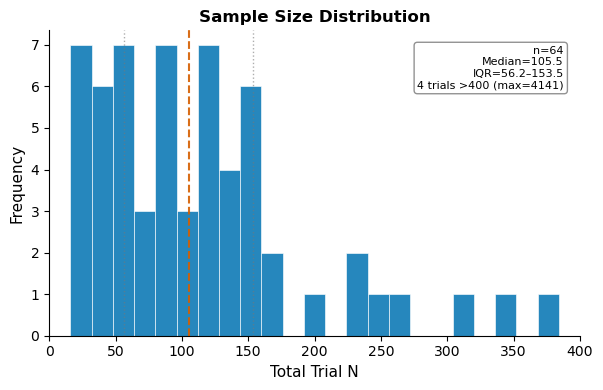

Sample size: median=106, IQR=56-154
Range: 17-4141
Pilot-scale trials (n<30): 5 / 64
  cov_nr: [157, 4108, 4123, 5339, 5777]


In [5]:
# Trial sample size distribution. Right tail trimmed at n=400 for readability.
# Pilot-scale (<30) trials flagged separately — typically feasibility studies.
trial_n = papers['total_n'].dropna()
n_cutoff = 400
n_outliers = (trial_n > n_cutoff).sum()
max_n = int(trial_n.max())
extra = f"{n_outliers} trials >{n_cutoff} (max={max_n})"
fig = histogram_with_stats(
    trial_n.values, xlabel="Total Trial N", title="Sample Size Distribution",
    bins=25, color=BLUE, extra_text=extra, hist_range=(0, n_cutoff),
)
ax = fig.axes[0]
ax.set_xlim(0, n_cutoff)
save_figure(fig, "fig1e_sample_size_distribution")

print(f"Sample size: median={trial_n.median():.0f}, IQR={trial_n.quantile(0.25):.0f}-{trial_n.quantile(0.75):.0f}")
print(f"Range: {trial_n.min():.0f}-{trial_n.max():.0f}")
pilot = papers[papers['total_n'] < 30]
print(f"Pilot-scale trials (n<30): {len(pilot)} / {len(papers)}")
if len(pilot) > 0:
    print(f"  cov_nr: {pilot['cov_nr'].tolist()}")


## Section 2.4: Healthcare setting

                           setting  n_arms        pct
0  Secondary / hospital outpatient     105  78.358209
1           Community / home-based      15  11.194030
2                     Primary care      14  10.447761
Saved: table2_setting_arm.csv


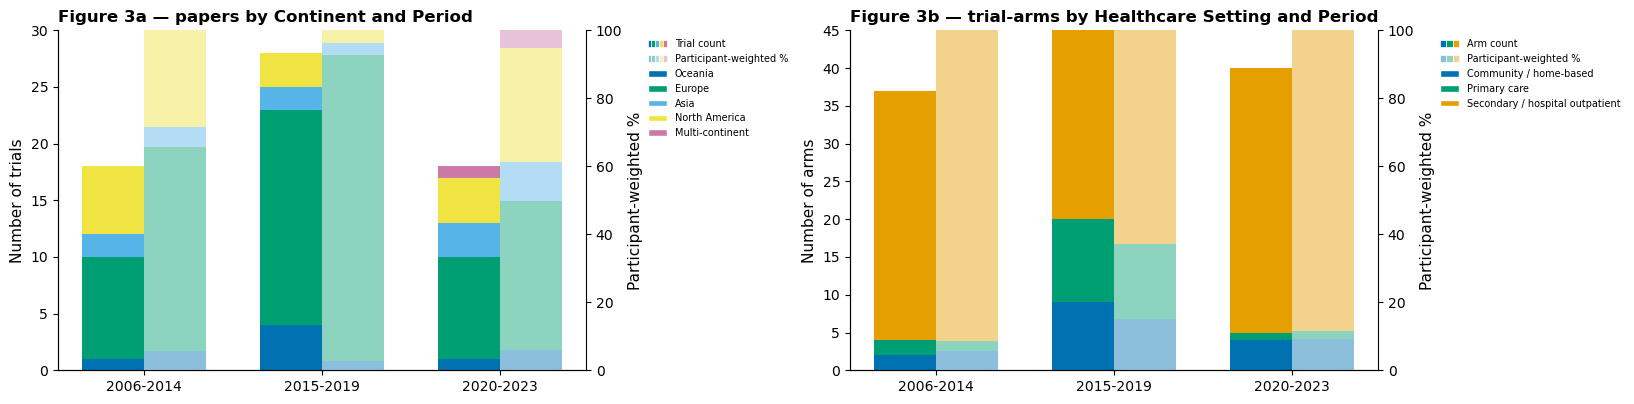

→ Thesis Figures 3a/3b (corpus composition)


In [6]:
# Healthcare setting: arm-level counts. Combined figure generated by
# build_fig_corpus_combined in this cell.

# Arm-level setting table and stacked bars (merge buckets without modifying arms)
arms_plot = arms.merge(papers[['cov_nr', 'bucket_eq', 'bucket_ph']], on='cov_nr', how='left')
arms_plot = arms_plot.dropna(subset=['bucket_eq', 'bucket_ph', 'healthcare_setting_label'])
setting_counts = arms_plot['healthcare_setting_label'].value_counts()
setting_df = pd.DataFrame({'setting': setting_counts.index, 'n_arms': setting_counts.values})
setting_df['pct'] = setting_df['n_arms'] / len(arms_plot) * 100
setting_df.to_csv(OUTPUT_TABLES / 'table2_setting_arm.csv', index=False)
print(setting_df.to_string())
print("Saved: table2_setting_arm.csv")

# Combined figure (continent + setting, dual-axis)
fig = build_fig_corpus_combined(papers, arms_plot)
save_figure(fig, "fig1a_corpus_combined")
print("→ Thesis Figures 3a/3b (corpus composition)")

## Section 2.5: Diagnosis distribution

In [7]:
# Classify each arm's diagnosis as 'COPD only' or 'COPD + other'
# by checking structured-array keys in the diagnosis field.
def classify_diagnosis(value):
    parsed = parse_structured_array(value)
    if parsed is None:
        return 'Unknown'
    keys = {k for k, _ in parsed if k.strip()}
    if any('COPD' not in k for k in keys):
        return 'COPD + other'
    return 'COPD only'

arms['diagnosis_class'] = arms['diagnosis'].apply(classify_diagnosis)
print("Diagnosis classification:")
print(arms['diagnosis_class'].value_counts().to_string())


Diagnosis classification:
diagnosis_class
COPD only       130
COPD + other      4


## Section 3.1: Participant-weighted baselines

**Participant-weighted aggregation:** For each baseline variable (age, %female,
FEV1%, BMI), we first compute the n-weighted mean across arms within each paper
(larger arms contribute more), then combine across papers — again weighted by
each paper's total N. This gives larger trials more influence on the pooled
estimate, matching a patient-level perspective (a trial with 400 patients
contributes more information than one with 40). Each aggregation step uses
`paper_level_weighted_mean()` from `src/aggregation.py`.


In [8]:
# Compute paper-level n-weighted means for 4 core baseline variables.
# Each arm weighted by its sample size; large arms contribute more.
baseline_cols = ['age_mean', 'gender_pct_female', 'fev1_pct_mean', 'bmi_mean']
paper_baselines = papers[['cov_nr', 'total_n']].copy()

for col in baseline_cols:
    wm = paper_level_weighted_mean(arms, col, 'n', 'cov_nr')
    paper_baselines[col] = paper_baselines['cov_nr'].map(wm)

paper_baselines.to_csv(ROOT / 'data' / 'processed' / 'papers_with_baseline.csv', index=False)

for col in baseline_cols:
    n_valid = paper_baselines[col].notna().sum()
    print(f"  {col}: {n_valid}/{len(papers)} papers with data")


  age_mean: 59/64 papers with data
  gender_pct_female: 61/64 papers with data
  fev1_pct_mean: 49/64 papers with data
  bmi_mean: 32/64 papers with data


## Section 3.2: Participant-weighted pooling

Each paper weighted by total N. Unweighted mean shown as sensitivity check.
Reference cohorts: ECLIPSE (international), Adelphi DSP (European),
Nijmegen CSI (Dutch outpatient + rehabilitation).


In [9]:
# Participant-weighted pooling across papers. Each paper weighted by total N.
# Unweighted mean shown as sensitivity check. Reference cohorts: ECLIPSE
# (international), Adelphi DSP (European), Nijmegen CSI (Dutch).
pooled = {}
for col in baseline_cols:
    p = pool_across_papers(paper_baselines, col, 'total_n')
    p_unw = unweighted_mean_across_papers(paper_baselines, col)
    pooled[col] = {**p, 'unweighted_mean': p_unw['mean']}
    print(f"\n{col}:")
    print(f"  Participant-weighted: {p['weighted_mean']:.1f} [{p['ci_lower']:.1f}, {p['ci_upper']:.1f}]  (each trial weighted by total N)")
    print(f"  Paper-weighted: {p_unw['mean']:.1f} [{p_unw['ci_lower']:.1f}, {p_unw['ci_upper']:.1f}]  (each trial = 1 vote)")
    print(f"  N papers: {p['n_papers']}")

# Build comparison table
stable = []
ref_labels = {
    'eclipse': ('ECLIPSE', 2164),
    'adelphi': ('Adelphi DSP', 2876),
    'nijmegen': ('Nijmegen outpatient', 168),
    'nijmegen_rehab': ('Nijmegen rehab', 131),
}
var_names = {
    'age_mean': ('Mean age (years)', 'age_years'),
    'gender_pct_female': ('% Female', 'female_pct'),
    'fev1_pct_mean': ('FEV1% predicted', 'fev1_pct_predicted'),
    'bmi_mean': ('BMI (kg/m2)', 'bmi_kg_m2'),
}

for var, (label, ref_key) in var_names.items():
    p = pooled[var]
    row = {
        'variable': label,
        'trial_estimate': f"{p['weighted_mean']:.1f}",
        'trial_95CI': f"[{p['ci_lower']:.1f}, {p['ci_upper']:.1f}]",
        'trial_SE': f"{p['se_weighted_mean']:.2f}" if p['se_weighted_mean'] is not None else '—',
        'n_trials': p['n_papers'],
    }
    for ref_name, (ref_label, ref_n) in ref_labels.items():
        ref = refs.get(ref_name, {}).get(ref_key, {})
        if ref:
            sd_str = f" ({ref['sd']:.1f})" if ref.get('sd') is not None else ''
            row[f'{ref_label}_mean_sd'] = f"{ref['mean']:.1f}{sd_str}"
            row[f'{ref_label}_n'] = ref['n']
        else:
            row[f'{ref_label}_mean_sd'] = '—'
            row[f'{ref_label}_n'] = '—'

    stable.append(row)

stable_df = pd.DataFrame(stable)
stable_df.to_csv(OUTPUT_TABLES / 'table3a_baseline_comparison.csv', index=False)
print("\nSaved: table3_baseline_comparison.csv")
pd.set_option('display.width', 300)
pd.set_option('display.max_columns', 15)
print(stable_df.to_string())



age_mean:
  Participant-weighted: 69.8 [68.4, 71.2]  (each trial weighted by total N)
  Paper-weighted: 68.4 [67.6, 69.2]  (each trial = 1 vote)
  N papers: 59

gender_pct_female:
  Participant-weighted: 46.0 [41.0, 51.0]  (each trial weighted by total N)
  Paper-weighted: 40.4 [36.0, 44.8]  (each trial = 1 vote)
  N papers: 61

fev1_pct_mean:
  Participant-weighted: 47.5 [45.4, 49.6]  (each trial weighted by total N)
  Paper-weighted: 48.2 [45.6, 50.8]  (each trial = 1 vote)
  N papers: 49

bmi_mean:
  Participant-weighted: 26.5 [25.6, 27.3]  (each trial weighted by total N)
  Paper-weighted: 26.5 [25.7, 27.3]  (each trial = 1 vote)
  N papers: 32

Saved: table3_baseline_comparison.csv
           variable trial_estimate    trial_95CI trial_SE  n_trials ECLIPSE_mean_sd  ECLIPSE_n Adelphi DSP_mean_sd  Adelphi DSP_n Nijmegen outpatient_mean_sd  Nijmegen outpatient_n Nijmegen rehab_mean_sd  Nijmegen rehab_n
0  Mean age (years)           69.8  [68.4, 71.2]     0.72        59      63.4 (7.

## Section 3.3: Comparison table

Trial pool estimates against 4 reference cohorts. Table saved to
`table3a_baseline_comparison.csv`.


## Section 3.4: Trial-level heterogeneity


In [10]:
# Compute within-trial pooled SDs via degrees-of-freedom weighting.
# Patient-level spread, comparable to reference cohort SDs.
sd_fields = {
    'age_mean': ('age_sd', 'age_years'),
    'fev1_pct_mean': ('fev1_pct_sd', 'fev1_pct_predicted'),
    'bmi_mean': ('bmi_sd', 'bmi_kg_m2'),
}
sd_comparison = {}
for var, (sd_col, ref_key) in sd_fields.items():
    result = pooled_within_trial_sd(arms, sd_col, 'n')
    ref_sds = {}
    for ref_name in ref_labels:
        ref = refs.get(ref_name, {}).get(ref_key, {})
        ref_sds[ref_name] = ref.get('sd')
    sd_comparison[var] = {**result, 'ref_sds': ref_sds}

# --- Shared plot setup ---
ref_order = ['eclipse', 'adelphi', 'nijmegen', 'nijmegen_rehab']
ref_labels_short = ['ECLIPSE (mean)', 'Adelphi DSP (mean)', 'Nijmegen CSI outpatient', 'Nijmegen CSI rehabilitation']
ref_colors = [ORANGE, GREEN, '#CC79A7', '#D55E00']


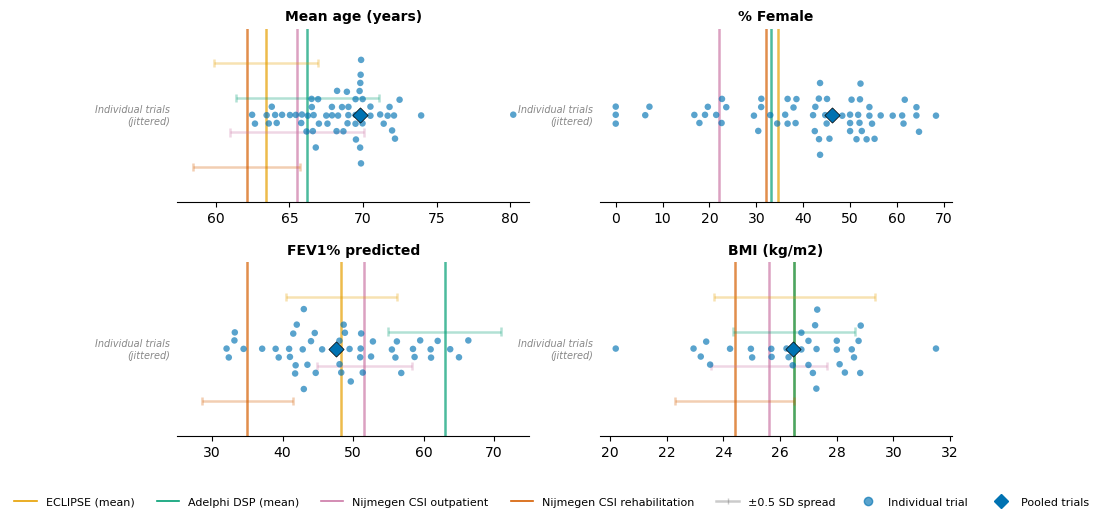

Saved: fig3_trial_scatter


In [11]:
# Per-trial beeswarm scatter: each dot = one trial's mean baseline value.
# Reference cohorts as vertical lines ± 0.5 SD I-bars.
# --- Trial-level scatter ---
fig = trial_scatter_means(
    paper_baselines, pooled, refs, var_names,
    ref_order, ref_labels_short, ref_colors,
    x_limits={'fev1_pct_mean': (25, 75)}
)
save_figure(fig, "fig3a_trial_scatter")
print("Saved: fig3_trial_scatter")

**Figure 3 — Trial-level heterogeneity:**

Each dot represents the mean baseline value from a single trial with beeswarm positioning to avoid overlap. The pooled estimate (diamond) and reference cohort means (solid lines) show how individual trial populations distribute relative to selected COPD cohorts. Horizontal I-bars show ±0.5 *SD* around each reference mean.

Reference cohorts: ECLIPSE (Evaluation of COPD Longitudinally to Identify Predictive Surrogate Endpoints) (mean), Adelphi DSP (Adelphi Disease-Specific Programme) (mean), Nijmegen CSI (Clinical Screening Instrument) outpatient, and Nijmegen CSI rehabilitation.

Note: Individual trials (jittered).


## Section 4.1: PROGRESS-Plus reporting (paper-level)

In [12]:
# PROGRESS-Plus reporting per domain. ambiguous_na from N01 flags unresolved
# cases. Social capital (combined) = reported if EITHER sub-field has data.
PROGRESS_PLUS_FIELDS = {
    'Place of residence': 'ses_living_location',
    'Ethnicity': 'ethnicity',
    'Occupation': 'ses_job_status',
    'Sex/gender': 'gender_pct_female',
    'Education': 'educational_level',
    'Income': 'ses_income',
    'Social capital (relationship)': 'ses_relationship_status',
    'Social capital (living)': 'ses_living_situation',
    'Health literacy': 'health_literacy',
    'Digital literacy': 'digital_literacy',
}

reporting_data = []
for label, field in PROGRESS_PLUS_FIELDS.items():
    amb_set = ambiguous_na.get(field, set()) if ambiguous_na else set()
    reporting = aggregate_equity_reporting(arms, field, ambiguous_cov_nrs=amb_set)
    n_reported = (reporting == 'reported').sum()
    n_not = (reporting == 'not_reported').sum()
    n_amb = (reporting == 'ambiguous').sum()

    prop = n_reported / (n_reported + n_not + n_amb)
    reporting_data.append({
        'domain': label, 'field': field,
        'reported': n_reported, 'not_reported': n_not, 'ambiguous': n_amb,
        'proportion': prop,
    })

# Social capital (combined): reported if EITHER relationship OR living is reported
rel_reporting = aggregate_equity_reporting(arms, 'ses_relationship_status',
    ambiguous_cov_nrs=ambiguous_na.get('ses_relationship_status', set()) if ambiguous_na else None)
liv_reporting = aggregate_equity_reporting(arms, 'ses_living_situation',
    ambiguous_cov_nrs=ambiguous_na.get('ses_living_situation', set()) if ambiguous_na else None)
n_combined = sum(1 for r, l in zip(rel_reporting, liv_reporting)
                if r == 'reported' or l == 'reported')
n_combined_amb = sum(1 for r, l in zip(rel_reporting, liv_reporting)
                     if (r == 'ambiguous' or l == 'ambiguous') and not (r == 'reported' or l == 'reported'))
n_combined_not = len(papers) - n_combined - n_combined_amb
prop_comb = n_combined / (n_combined + n_combined_not + n_combined_amb)
reporting_data.append({
    'domain': 'Social capital (combined)', 'field': '',
    'reported': n_combined, 'not_reported': n_combined_not, 'ambiguous': n_combined_amb,
    'proportion': prop_comb,
})

rdf = pd.DataFrame(reporting_data).sort_values('proportion')
print(rdf[['domain', 'reported', 'not_reported', 'ambiguous', 'proportion']].to_string())

# Print paper IDs for 3 non-reporting sex/gender papers — auditable.
sex_reporting = aggregate_equity_reporting(arms, 'gender_pct_female')
sex_not = sex_reporting[sex_reporting != 'reported'].index.tolist()
print(f"Papers NOT reporting sex/gender (n={len(sex_not)}): {sex_not}")
print(f"Papers reporting sex/gender: {len(sex_reporting[sex_reporting == "reported"])} / {len(papers)}")


                           domain  reported  not_reported  ambiguous  proportion
0              Place of residence         4            60          0    0.062500
5                          Income         5            57          2    0.078125
6   Social capital (relationship)         8            55          1    0.125000
9                Digital literacy        10            54          0    0.156250
2                      Occupation        11            53          0    0.171875
1                       Ethnicity        11            53          0    0.171875
8                 Health literacy        13            51          0    0.203125
7         Social capital (living)        17            46          1    0.265625
4                       Education        18            45          1    0.281250
10      Social capital (combined)        23            40          1    0.359375
3                      Sex/gender        61             3          0    0.953125
Papers NOT reporting sex/gen

## Section 4.2: Save PROGRESS-Plus table


In [13]:
# Save PROGRESS-Plus reporting table.
rdf.to_csv(OUTPUT_TABLES / 'table4_progress_plus_reporting.csv', index=False)
print("Saved: table4_progress_plus_reporting.csv")


Saved: table4_progress_plus_reporting.csv


## Section 4.3: Reporting completeness figure


**Note:** The combined PROGRESS-Plus figure (`fig4_combined`) is generated
by `scripts/build_fig4_combined.py`, which requires the equity score computed
in Notebook 04. This section will call `build_fig4_combined(papers, arms)`
after Notebooks 03, 04, and 05 are merged.


## Section 5.1: Digital strategy aggregation

**Boolean aggregation from arm-level to paper-level:** Each arm records whether
it excludes participants, provides equipment, training, or ongoing support
(True/False per arm). Using `aggregate_boolean_at_paper()` from
`src/aggregation.py`, we collapse to paper-level: a strategy is marked present
for the paper if **any** of its arms has it True, and absent only if **all**
arms have it False. This avoids double-counting multi-arm trials as separate
data points when analysing paper-level prevalence.


In [14]:
# Digital strategy: aggregate 4 binary arm-level flags → paper-level.
# method='any_true': trial 'has' strategy if any arm has it True.
ds_fields = [
    'digital_strategy_excludes', 'digital_strategy_provides_equipment',
    'digital_strategy_provides_training', 'digital_strategy_provides_ongoing_support',
]
ds_labels = ['Excludes', 'Provides equipment', 'Provides training', 'Provides ongoing support']

ds_paper = papers[['cov_nr', 'healthcare_setting']].copy()
for field in ds_fields:
    ds_paper[field] = aggregate_boolean_at_paper(int_arms, field, method="any_true").values

# Overall proportions
ds_data = []
for field, label in zip(ds_fields, ds_labels):
    n_true = ds_paper[field].sum()
    n_false = (ds_paper[field] == 0).sum()
    prop = n_true / (n_true + n_false)
    ds_data.append({
        'strategy': label, 'field': field,
        'n_yes': n_true, 'n_no': n_false,
        'proportion': prop,
    })

dsd = pd.DataFrame(ds_data)
print(dsd.to_string())
dsd.to_csv(OUTPUT_TABLES / 'table5_digital_strategy.csv', index=False)
print("\nSaved: table5_digital_strategy.csv")


                   strategy                                      field  n_yes  n_no  proportion
0                  Excludes                  digital_strategy_excludes     37    27    0.578125
1        Provides equipment        digital_strategy_provides_equipment     33    31    0.515625
2         Provides training         digital_strategy_provides_training     40    24    0.625000
3  Provides ongoing support  digital_strategy_provides_ongoing_support     26    38    0.406250

Saved: table5_digital_strategy.csv


## Section 6: Summary export

In [15]:
paper_setting_counts = papers['healthcare_setting_label'].value_counts()
summary = {
    'n_trials': len(papers),
    'n_arms': len(arms),
    'year_range': f"{years.min():.0f}-{years.max():.0f}",
    'total_participants': int(papers['total_n'].sum()),
    'n_countries': len(country_counts),
    'pct_primary': float(paper_setting_counts.get('Primary care', 0) / len(papers) * 100),
    'pct_secondary': float(paper_setting_counts.get('Secondary / hospital outpatient', 0) / len(papers) * 100),
    'pct_community': float(paper_setting_counts.get('Community / home-based', 0) / len(papers) * 100),
}

for var in baseline_cols:
    if var in pooled:
        p = pooled[var]
        summary[f'{var}_pooled'] = p['weighted_mean']
        summary[f'{var}_ci_lo'] = p['ci_lower']
        summary[f'{var}_ci_hi'] = p['ci_upper']

summary_df = pd.DataFrame([summary])
summary_df.to_csv(OUTPUT_TABLES / 'table3c_representativeness_summary.csv', index=False)
print("Saved: representativeness_summary.csv")

print("\n=== Notebook 03 complete ===")
print(f"All outputs in outputs/figures/ and outputs/tables/")


Saved: representativeness_summary.csv

=== Notebook 03 complete ===
All outputs in outputs/figures/ and outputs/tables/


## Garbage Bin — kill your children

Old headers and explanatory text moved here during refactoring.
These figures are Appendix content; the code remains functional
but the prose below is retained for reference only.

### Old Section 3.2–3.3 educational content

**Standard Deviation (SD)** measures the spread of individual patients around
their mean. For each trial arm we have a reported SD; we combine them into a
*within-trial pooled SD* using degrees-of-freedom weighting (the meta-analytic
formula). This gives a patient-level quantity comparable to what reference
cohorts report. SD does not shrink with larger samples — it measures spread of
individuals, not precision of estimates.

**Standard Error (SE)** is the precision of the *mean* estimate: SE = SD / √n.
Larger n → smaller SE → more precise mean. A cohort with n=2000 and SD=15 has
SE ≈ 0.34; one with n=200 and the same SD has SE ≈ 1.06. Same patient spread,
very different precision.

| Quantity | What it measures | Shrinks with n? |
|----------|-----------------|-----------------|
| SD | Patient-level spread | No |
| SE | Precision of the mean | Yes (SE = SD / √n) |

**Confidence Interval (CI)** is a range around an estimate intended to capture
the true parameter in 95% of repeated samples (if the analysis were run many
times). For a mean: 95% CI ≈ mean ± 1.96 × SE. A narrow CI = precise estimate;
a wide CI = imprecise estimate.

> **How to read overlap:** CIs that overlap between the trial pool and a
> reference cohort are *suggestive* of comparability, but overlap of two 95% CIs
> does **not** directly map to "no statistical difference." The comparison is
> descriptive, not a formal test.

In the table below, each baseline variable shows:
- **Trial pool** — participant-weighted mean, 95% CI, and pooled SD
- **Reference cohorts** — mean, 95% CI (computed from their reported n and SD), and reported SD

### Old Section 4.2–4.3 Wilson CI explanation

**Wilson confidence interval** is a method for computing CIs on proportions that
is more accurate than the simple “mean ± 1.96 × SE” approach, especially at
small sample sizes or extreme proportions (near 0% or 100%).

For each PROGRESS-Plus variable we compute:
- **n_reported** / 65 papers → proportion
- **Wilson 95% CI** around that proportion

The Wilson interval behaves sensibly at boundaries: near 0% or 100%, the
simple Wald interval becomes pathologically narrow (0% ± 0%), while the
Wilson interval correctly widens to reflect the uncertainty of a rare or
near-ubiquitous event.

We also note the **number of arms** alongside the paper-level count, since
multi-arm trials contribute multiple observations within the same paper.

### Appendix A: Participant-level spread — mean ± 1.96 SD

**Appendix Figure A:** Dots represent mean estimates; whiskers show patient-level spread (mean ± 1.96 × SD), covering ~95% of individuals within each cohort, not precision of the mean estimate. Abbreviations: OP = outpatient; PR = pulmonary rehabilitation; DSP = disease-specific programme. The blue Trial pooled row is drawn thicker to distinguish it from the reference cohorts.

### Appendix B: Baseline cohort comparison (SE-CI)

**Appendix Figure B — Baseline cohort comparison (SE-CI):** Dots represent mean estimates; whiskers show 95% confidence intervals. Reference cohorts (ECLIPSE, Adelphi DSP, Nijmegen CSI outpatient group, Nijmegen CSI rehabilitation group) have very large sample sizes (N=131–2876), so their CIs are too narrow to appear as visible whiskers at this scale. The blue Trial pooled row is drawn with a thicker line and larger marker to distinguish it from the reference cohorts.

### Appendix C: Standardized mean differences

**Appendix Figure C — SMD representativeness:**

Dots represent standardized mean differences (trial mean − reference mean) divided by the pooled standard deviation (*SD*~pooled~ = √((*SD*~trial~² + *SD*~ref~²)/2)). Positive values indicate trials enrolled patients with higher values than the reference cohort; negative values indicate lower values.

Shaded bands show conventional covariate-balance thresholds: ±0.1 (negligible), ±0.25 (acceptable), and ±0.5 (moderate). For the % Female row, the metric is Cohen's *h* (not SMD), because no within-trial SD is available for a proportion variable.

Reference cohorts: ECLIPSE (Evaluation of COPD Longitudinally to Identify Predictive Surrogate Endpoints), Adelphi DSP (Adelphi Disease-Specific Programme), Nijmegen CSI (Clinical Screening Instrument) outpatient group, and Nijmegen CSI rehabilitation group.


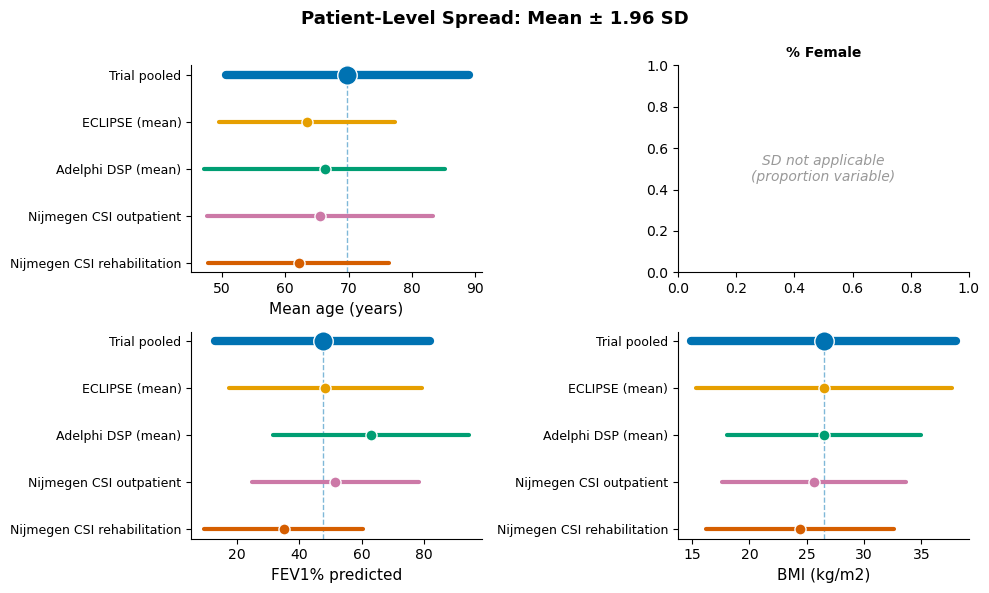

Saved: fig3_patient_spread_sd
Whiskers show mean ± 1.96 × SD — the range covering ~95% of individuals per cohort, not precision of the mean estimate.


In [16]:
# Appendix A: Patient-level spread — mean ± 1.96 × SD
# %Female excluded — no within-trial SD for a proportion variable;
# the panel shows "not applicable" annotation by the plotting function.
sd_var_names = {
    'age_mean': ('Mean age (years)', 'age_years'),
    'gender_pct_female': ('% Female', 'female_pct'),
    'fev1_pct_mean': ('FEV1% predicted', 'fev1_pct_predicted'),
    'bmi_mean': ('BMI (kg/m2)', 'bmi_kg_m2'),
}

fig = forest_plot_means(
    pooled, refs, sd_var_names, ref_order, ref_labels_short, ref_colors,
    spread="sd", trial_sd_comparison=sd_comparison,
)
save_figure(fig, "fig3b_patient_spread_sd")
print("Saved: fig3_patient_spread_sd")
print("Whiskers show mean ± 1.96 × SD — the range covering ~95% of "
      "individuals per cohort, not precision of the mean estimate.")


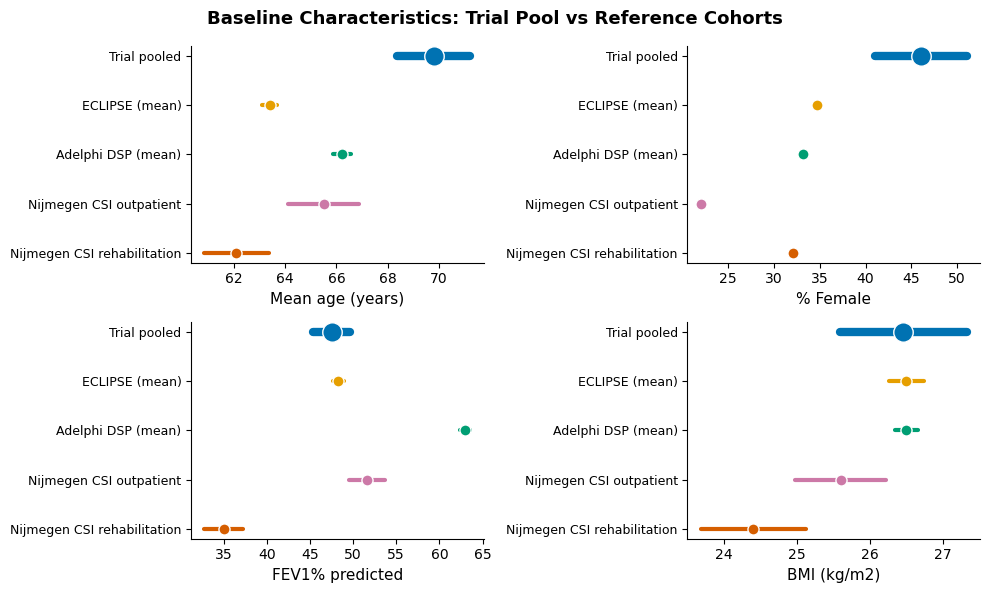

Saved: fig3_baseline_cohort_comparison


In [17]:
# Appendix B: Baseline cohort comparison (SE-CI)
# --- Forest plot: means with 95% CI ---
fig = forest_plot_means(
    pooled, refs, var_names, ref_order, ref_labels_short, ref_colors,
    spread="se", show_trial_ref_line=False,
)
save_figure(fig, "fig3e_baseline_cohort_comparison")
print("Saved: fig3_baseline_cohort_comparison")
